In [55]:
import numpy as np
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")

In [56]:
print(df.head())
print(df.describe().T)
print(df.info())
print(df.shape)
print(df['Class'].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

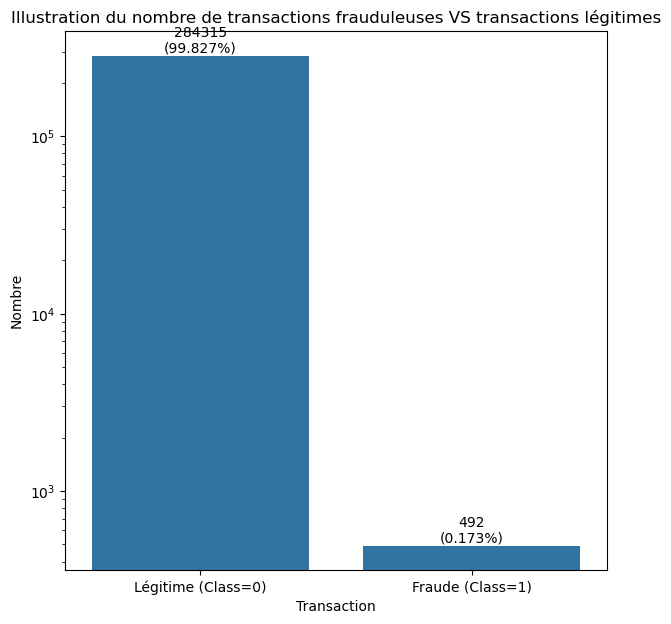

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,7))
ax = sns.countplot(x=df['Class'])
ax.set_yscale('log')
plt.title("Illustration du nombre de transactions frauduleuses VS transactions légitimes")

plt.xlabel("Transaction")
plt.ylabel("Nombre")
ax.set_xticks([0, 1])
ax.set_xticklabels(['Légitime (Class=0)', 'Fraude (Class=1)']) 

# Annoter chaque barre avec valeur + pourcentage
for p in ax.patches:
    count = p.get_height()
    pct = 100 * count / len(df)
    ax.annotate(f'{int(count)}\n({pct:.3f}%)', 
                (p.get_x() + p.get_width()/2, count),
                ha='center', va='bottom')

plt.show()

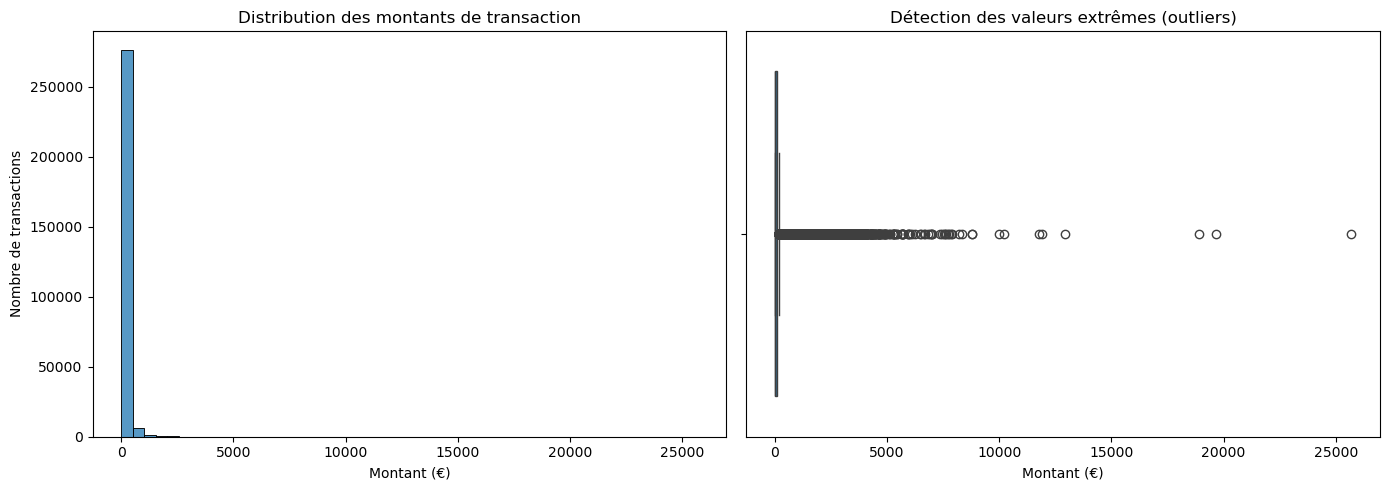

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df['Amount'], bins=50, ax=axes[0])
axes[0].set_title("Distribution des montants de transaction")
axes[0].set_xlabel("Montant (€)")
axes[0].set_ylabel("Nombre de transactions")

sns.boxplot(x=df['Amount'], ax=axes[1])
axes[1].set_title("Détection des valeurs extrêmes (outliers)")
axes[1].set_xlabel("Montant (€)")

plt.tight_layout()
plt.show()

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


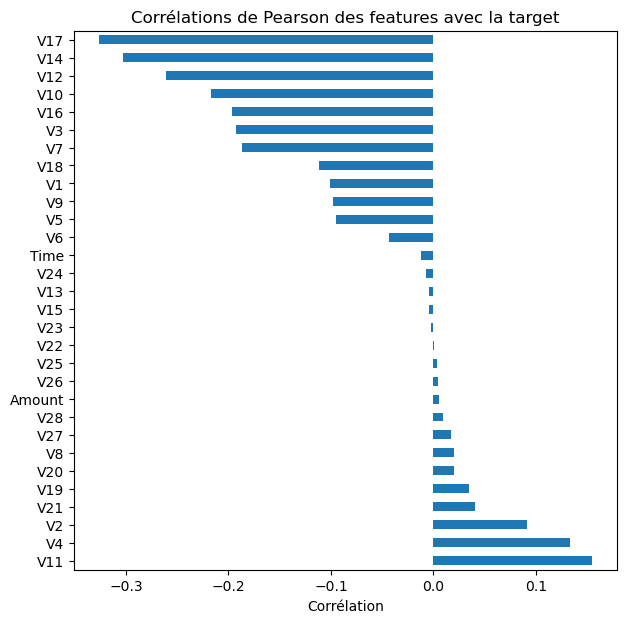

In [59]:
corr_matrix = df.corr()

corr_with_class = corr_matrix['Class'].sort_values(ascending=False)
print(corr_with_class)

plt.figure(figsize=(7,7))
corr_with_class.drop('Class').plot(kind='barh')
plt.title("Corrélations de Pearson des features avec la target")
plt.xlabel("Corrélation")
plt.show()

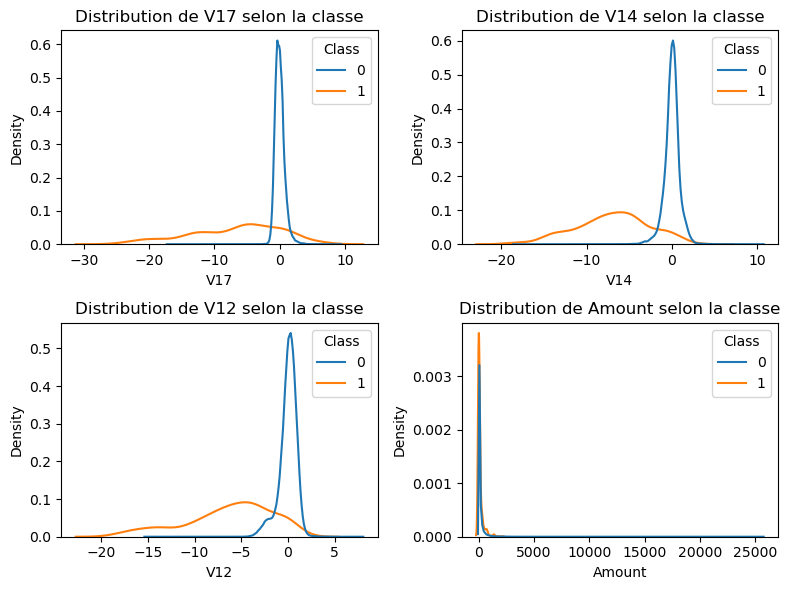

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(8,6))

variables = ['V17', 'V14', 'V12', 'Amount']

for i, var in enumerate(variables):
    ax = axes[i//2, i%2]
    sns.kdeplot(data=df, x=var, hue='Class', ax=ax, common_norm=False)
    ax.set_title(f"Distribution de {var} selon la classe")

plt.tight_layout()
plt.show()

In [61]:
df.duplicated().sum()

np.int64(1081)

In [62]:
df[df.duplicated()]['Class'].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

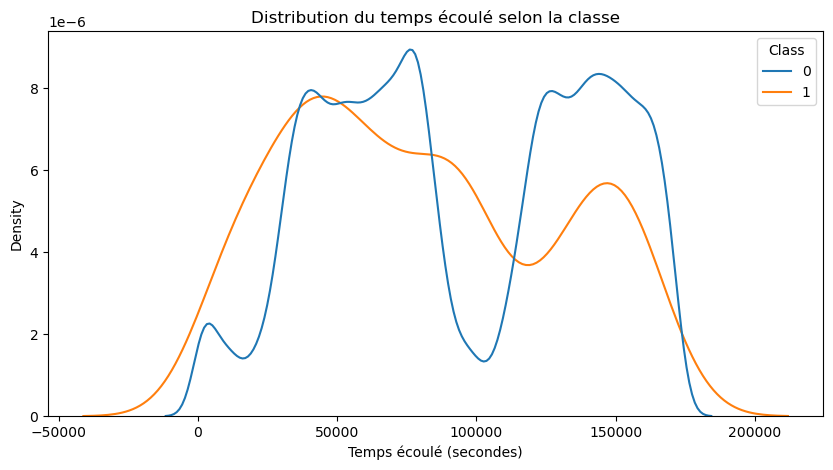

In [70]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x='Time', hue='Class', common_norm=False)
plt.title("Distribution du temps écoulé selon la classe")
plt.xlabel("Temps écoulé (secondes)")
plt.show()

In [71]:
df_clean = df.drop_duplicates()
print(df_clean.shape)

X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(283726, 31)
Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)    

model_baseline = LogisticRegression(max_iter=1000, random_state=42)
model_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = model_baseline.predict(X_test_scaled)
y_proba_baseline = model_baseline.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_baseline))
print("PR-AUC:", average_precision_score(y_test, y_proba_baseline))
print(confusion_matrix(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.6919665484964556
[[56641    10]
 [   40    55]]


In [74]:
model_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = model_weighted.predict(X_test_scaled)
y_proba_weighted = model_weighted.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_weighted))
print("PR-AUC:", average_precision_score(y_test, y_proba_weighted))
print(confusion_matrix(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

PR-AUC: 0.6719244530518994
[[55262  1389]
 [   12    83]]


In [75]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)
y_proba_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("PR-AUC:", average_precision_score(y_test, y_proba_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.795816464020689
[[56649     2]
 [   28    67]]


In [76]:
pip install xgboost --break-system-packages

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.3/69.5 MB 7.4 MB/s eta 0:00:10
   - -------------------------------------- 2.9/69.5 MB 7.1 MB/s eta 0:00:10
   -- ------------------------------------- 4.5/69.5 MB 7.0 MB/s eta 0:00:10
   --- ------------------------------------ 6.0/69.5 MB 7.1 MB/s eta 0:00:09
   ---- ----------------------------------- 7.6/69.5 MB 7.2 MB/s eta 0:00:09
   ----- ---------------------------------- 9.2/69.5 MB 7.2 MB/s eta 0:00:09
   ------ --------------------------------- 10.7/69.5 MB 7.3 MB/s eta 0:00:09
   ------- -------------------------------- 12.6/69.5 MB 7.4 MB/s eta 0:00:08
   ------- -------------------------------- 13.9/69.5 MB 7.4 MB/s eta 0:00:08
   --------- ------------------------------ 15.7/69.5 MB 7.4 MB/s eta 0:00:08
   --------- ------------------------------ 17.3/69.5 MB 7.5 MB/s eta 0:00:07
   ---------- ----------------------------- 18.9/69.5 MB 7.5 MB/s eta 0:00:07


In [78]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=100, 
    random_state=42, 
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr'
)
model_xgb.fit(X_train_scaled, y_train)

y_pred_xgb = model_xgb.predict(X_test_scaled)
y_proba_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("PR-AUC:", average_precision_score(y_test, y_proba_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.78      0.87        95

    accuracy                           1.00     56746
   macro avg       0.99      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.825107964521263
[[56649     2]
 [   21    74]]


In [80]:
from sklearn.metrics import precision_recall_curve, fbeta_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

f2_scores = (1 + 2**2) * (precisions * recalls) / (2**2 * precisions + recalls + 1e-10)

best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

print(f"Meilleur seuil (max F2) : {best_threshold:.4f}")
print(f"Precision à ce seuil : {precisions[best_idx]:.3f}")
print(f"Recall à ce seuil : {recalls[best_idx]:.3f}")
print(f"F2-score à ce seuil : {f2_scores[best_idx]:.3f}")

Meilleur seuil (max F2) : 0.2623
Precision à ce seuil : 0.916
Recall à ce seuil : 0.800
F2-score à ce seuil : 0.821


In [81]:
y_pred_custom = (y_proba_xgb >= best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_custom))

[[56644     7]
 [   19    76]]


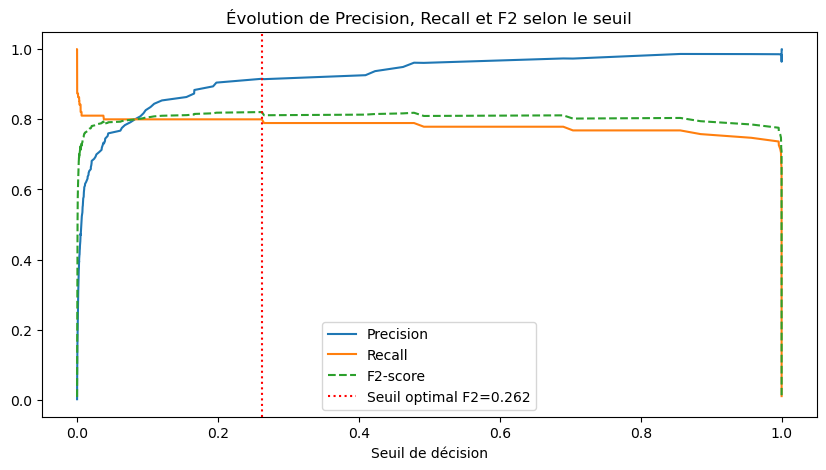

In [82]:
plt.figure(figsize=(10,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f2_scores[:-1], label='F2-score', linestyle='--')
plt.axvline(best_threshold, color='red', linestyle=':', label=f'Seuil optimal F2={best_threshold:.3f}')
plt.xlabel("Seuil de décision")
plt.legend()
plt.title("Évolution de Precision, Recall et F2 selon le seuil")
plt.show()

Text(0.5, 1.0, 'Courbe Precision-Recall')

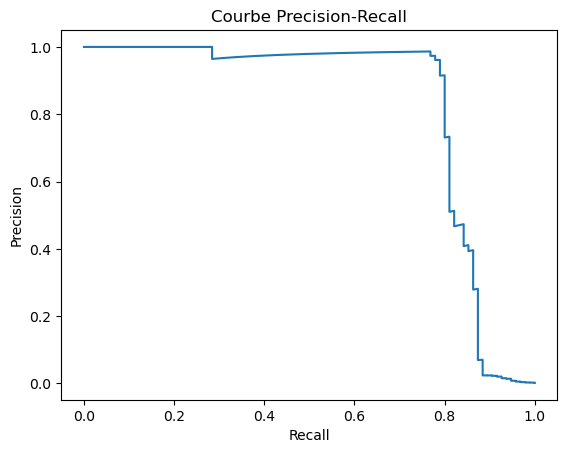

In [84]:
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall")

In [85]:
pip install shap --break-system-packages

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.3/41.9 MB 6.3 MB/s eta 0:00:07
   -- ------------------------------------- 2.6/41.9 MB 6.6 MB/s eta 0:00:06
   ---- ----------------------------------- 4.2/41.9 MB 6.5 MB/s eta 0:00:06
   ----- ---------------------------------- 5.5/41.9 MB 6.5 MB/s eta 0:00:06
   ------ --------------------------------- 7.1/41.9 MB 6.5 MB/s eta 0:00:06
   ------- -------------------------------- 8.1/41.9 MB 6.4 MB/s eta 0:00:06
   --------- ------------------------------ 9.4/41.9 MB 6.5 MB/s eta 0:00:06
   ---------- ----------------------------- 11.0/41.9 MB 6.5 MB/s eta 0:00:05
   ----------- ---------------------------- 12.3/41.9 MB 6.4 MB/s eta 0:00:05
   ------------- -------------------------- 13.6/41.9 MB 6.4 MB/s eta 0:00:05
   -------------- ------------------------- 14.9/41.9 MB 6.5 MB/s eta 0:00:05
   --------------- ------------------------ 16.5/41.9 MB 6.5 MB/s eta 0:00:04
 

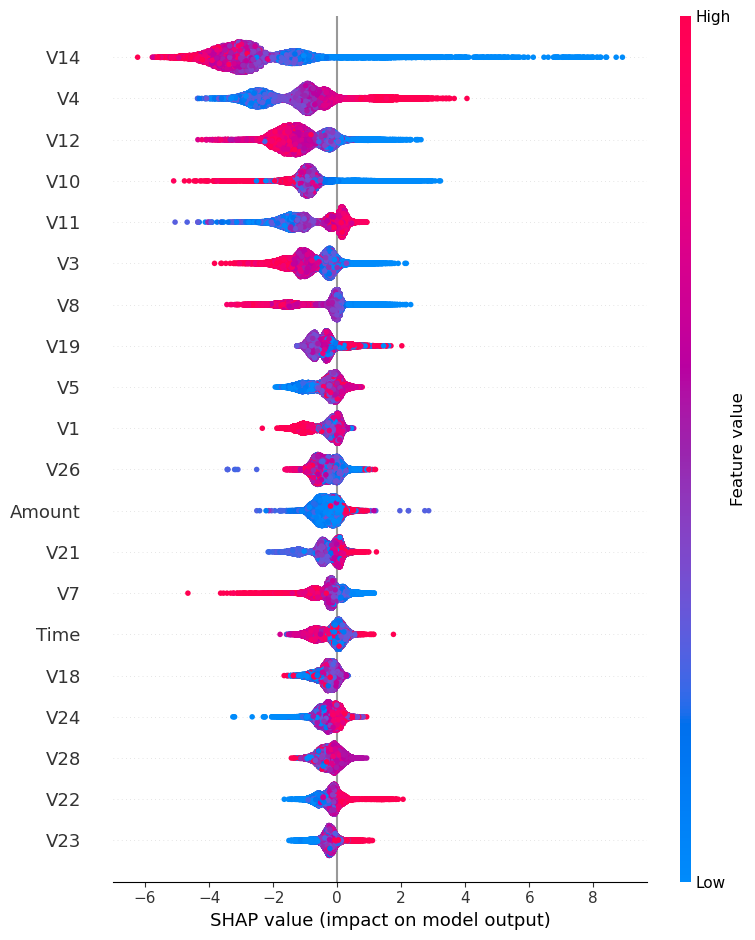

In [86]:
import shap

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)

In [ ]:
y